In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt

def parse_loss_log(path):
    """
    Parse a loss_log.txt file into a pandas DataFrame, including Rank.
    """
    pattern = re.compile(
        r"\[Rank\s*(?P<rank>\d+)\]\s*"
        r"\(epoch:\s*(?P<epoch>\d+),\s*iters:\s*(?P<iters>\d+),\s*time:\s*(?P<time>[\d.]+),\s*data:\s*(?P<data>[\d.]+)\)\s*,\s*"
        r"G_GAN:\s*(?P<G_GAN>[\d.]+),\s*G_L1:\s*(?P<G_L1>[\d.]+),\s*D_real:\s*(?P<D_real>[\d.]+),\s*D_fake:\s*(?P<D_fake>[\d.]+)"
    )

    rows = []

    with open(path, "r") as f:
        for line in f:
            match = pattern.search(line)
            if match:
                row = match.groupdict()
                
                # Convert numeric fields
                row = {
                    k: (int(v) if k in ("rank", "epoch", "iters") else float(v))
                    for k, v in row.items()
                }
                
                rows.append(row)

    return pd.DataFrame(rows)

def parse_loss_log_pure_swin(path):
    """
    Parse a loss_log.txt file into a pandas DataFrame, including Rank.
    """
    pattern = re.compile(
        r"\[Rank\s*(?P<rank>\d+)\]\s*"
        r"\(epoch:\s*(?P<epoch>\d+),\s*iters:\s*(?P<iters>\d+),\s*time:\s*(?P<time>[\d.]+),\s*data:\s*(?P<data>[\d.]+)\)\s*,\s*"
        r"L1:\s*(?P<L1>[\d.]+)"
    )

    rows = []

    with open(path, "r") as f:
        for line in f:
            match = pattern.search(line)
            if match:
                row = match.groupdict()
                
                # Convert numeric fields
                row = {
                    k: (int(v) if k in ("rank", "epoch", "iters") else float(v))
                    for k, v in row.items()
                }
                
                rows.append(row)

    return pd.DataFrame(rows)

def plot_metric_mean_per_epoch(df, metric, title=None):
    """
    Aggregate means of the four metrics per epoch and plot the selected metric.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing at least: epoch, G_GAN, G_L1, D_real, D_fake
    metric : str
        One of: "G_GAN", "G_L1", "D_real", "D_fake"
    title : str, optional
        Optional custom plot title.
    """
    
    allowed = ["G_GAN", "G_L1", "D_real", "D_fake"]
    if metric not in allowed:
        raise ValueError(f"metric must be one of {allowed}")

    # Compute mean of each metric per epoch
    df_mean = df.groupby("epoch")[allowed].mean()

    plt.figure(figsize=(8, 5))
    plt.plot(df_mean.index, df_mean[metric], marker="o")
    plt.xlabel("Epoch")
    plt.ylabel(f"Mean {metric}")
    plt.title(title or f"Mean {metric} per Epoch")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # return df_mean  # convenient if the caller wants the aggregated table

def plot_all_metric_means_per_epoch(df, title="Mean Metrics per Epoch", metrics = ['G_GAN', 'G_L1', 'D_real', 'D_fake']):
    """
    Compute mean values per epoch for the four metrics and plot them
    in a 2x2 grid.
    """

    # Compute means once
    df_mean = df.groupby("epoch")[metrics].mean()

    # Create 2×2 subplot layout
    fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True)

    for ax, metric in zip(axes.flatten(), metrics):
        ax.plot(df_mean.index, df_mean[metric], marker='o')
        ax.set_title(metric)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Mean Value")
        ax.grid(True)

    # Add main title
    fig.suptitle(title, fontsize=18, y=0.98)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    # return df_mean

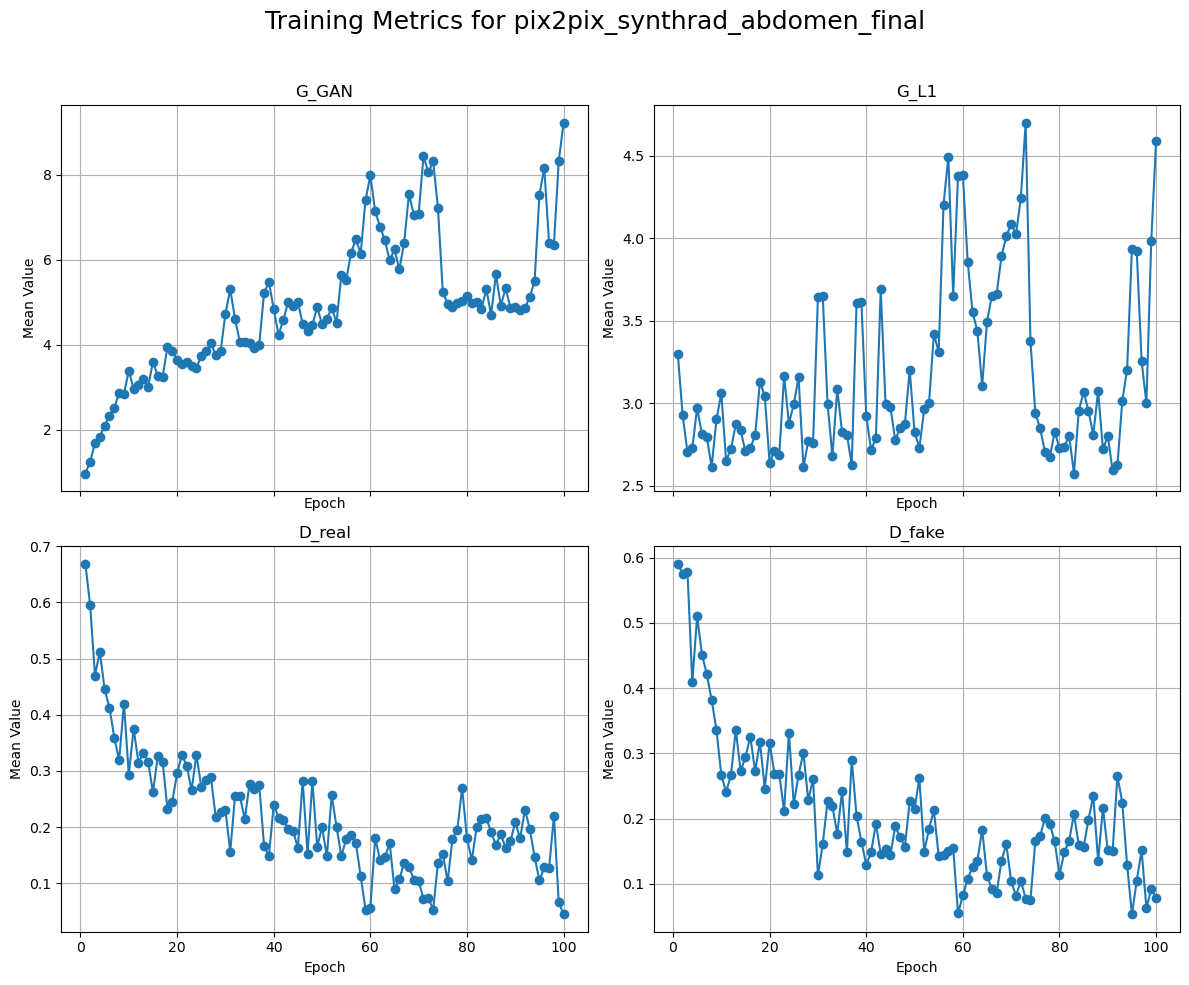

In [2]:
checkpoints_dir = "/local/scratch/datasets/FullbodySCT/Synthrad_combined_preprocessed/8checkpoints/"
name = "pix2pix_synthrad_abdomen_final"

loss_log = parse_loss_log(checkpoints_dir+name+"/loss_log.txt")
plot_all_metric_means_per_epoch(loss_log, title=f"Training Metrics for {name}")

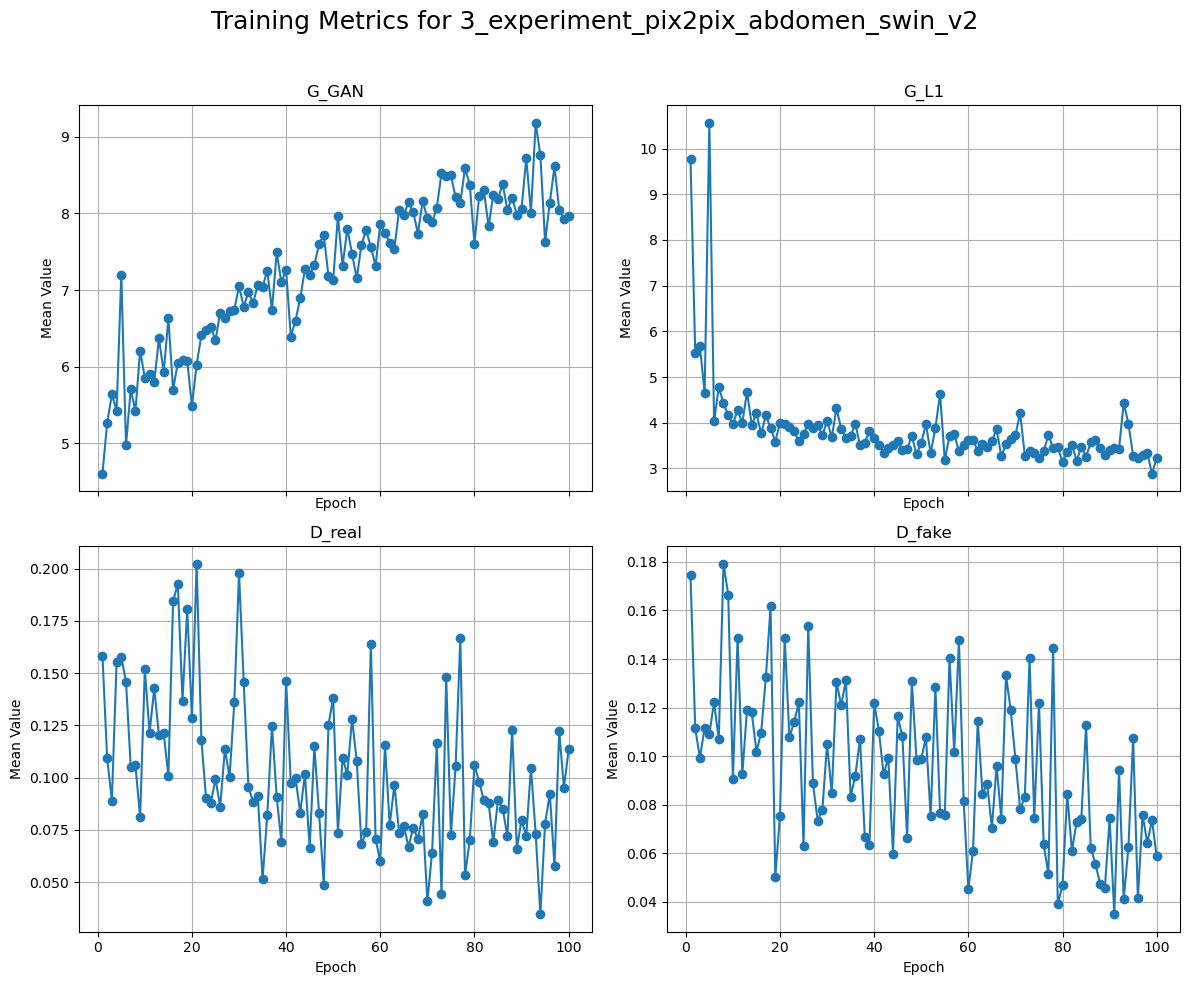

In [3]:
checkpoints_dir = "/local/scratch/datasets/FullbodySCT/Synthrad_combined_preprocessed/8checkpoints/"
name = "3_experiment_pix2pix_abdomen_swin_v2"

loss_log = parse_loss_log(checkpoints_dir+name+"/loss_log.txt")
plot_all_metric_means_per_epoch(loss_log, title=f"Training Metrics for {name}")

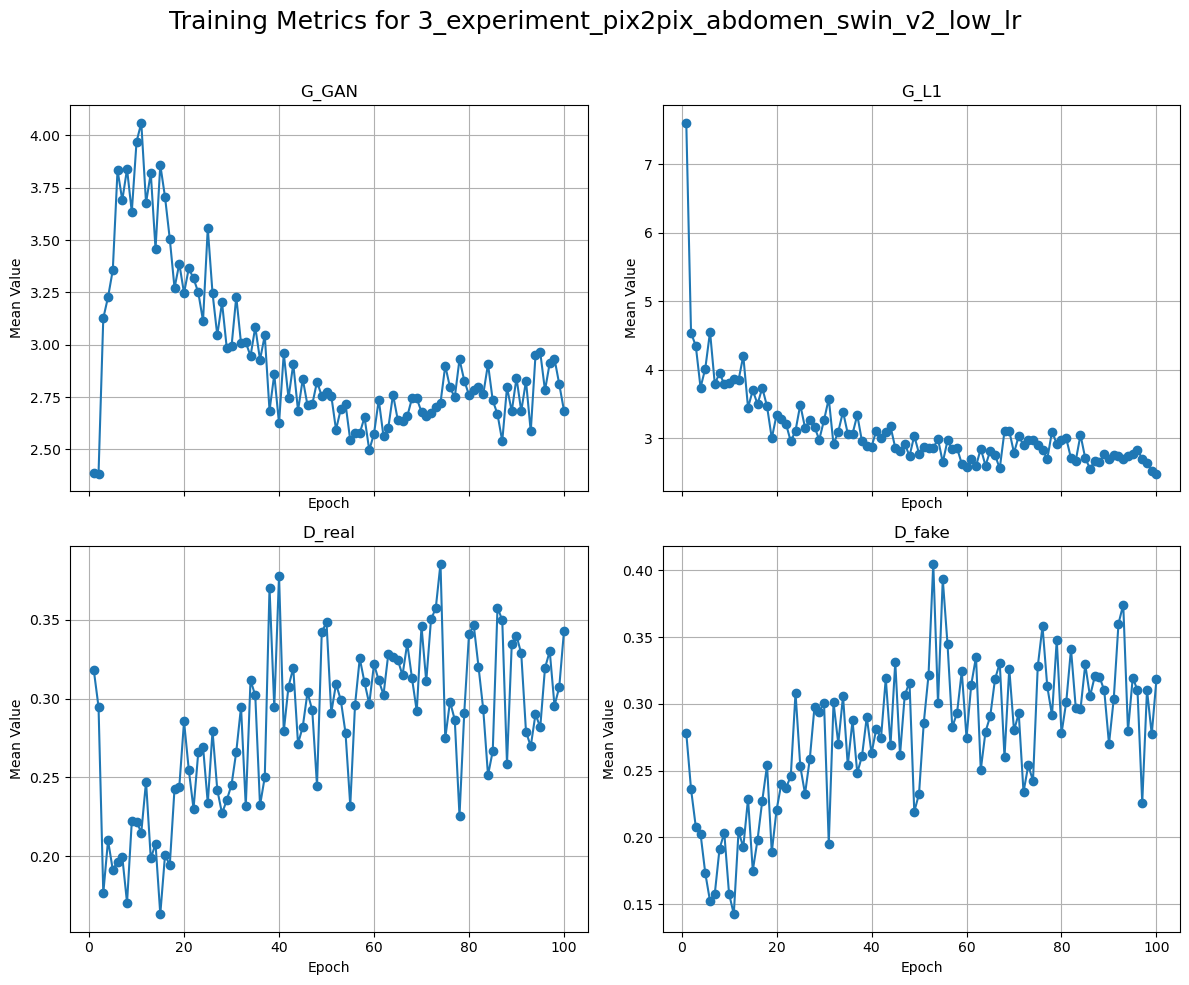

In [4]:
checkpoints_dir = "/local/scratch/datasets/FullbodySCT/Synthrad_combined_preprocessed/8checkpoints/"
name = "3_experiment_pix2pix_abdomen_swin_v2_low_lr"

loss_log = parse_loss_log(checkpoints_dir+name+"/loss_log.txt")
plot_all_metric_means_per_epoch(loss_log, title=f"Training Metrics for {name}")

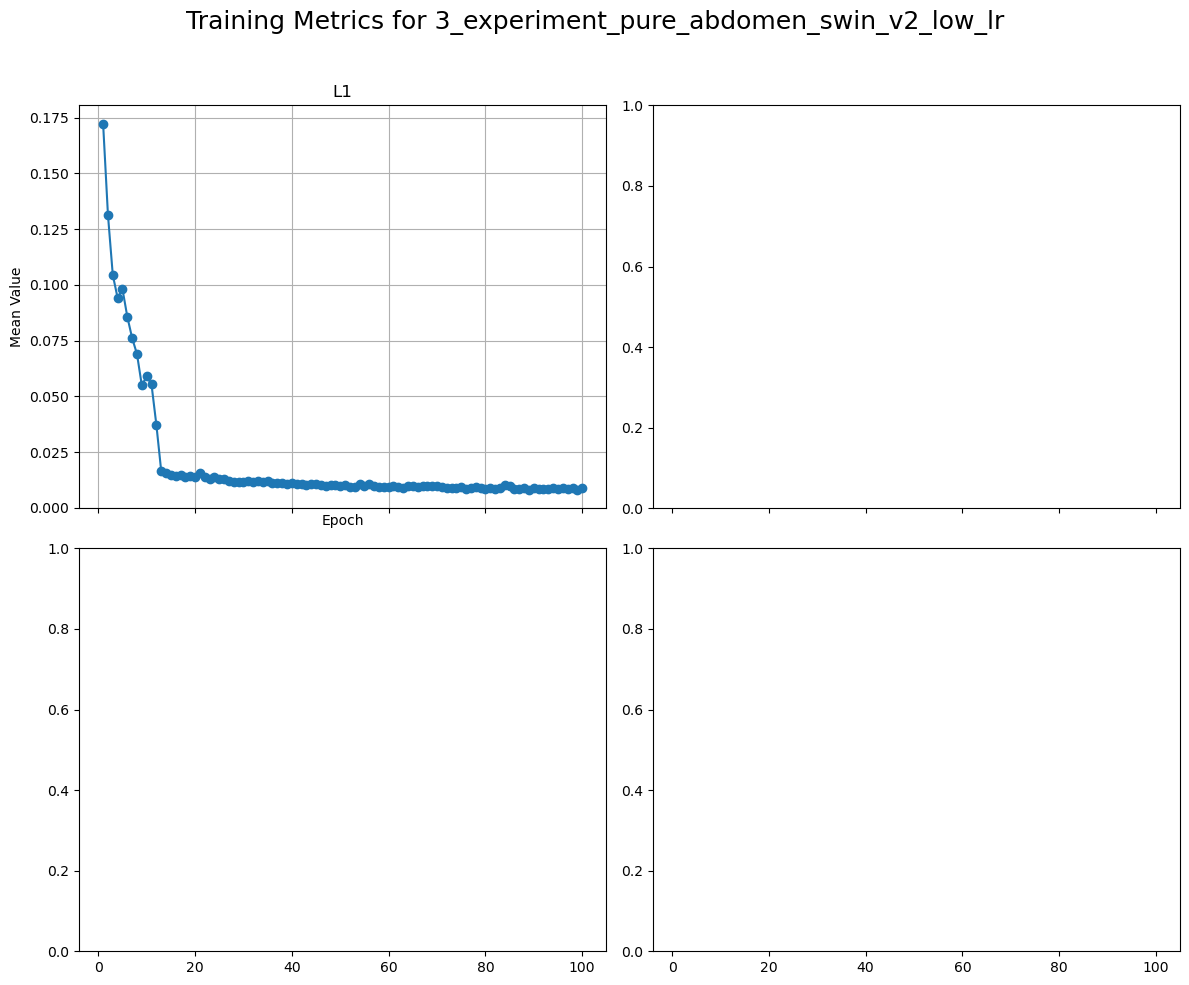

In [5]:
checkpoints_dir = "/local/scratch/datasets/FullbodySCT/Synthrad_combined_preprocessed/8checkpoints/"
name = "3_experiment_pure_abdomen_swin_v2_low_lr"

loss_log = parse_loss_log_pure_swin(checkpoints_dir+name+"/loss_log.txt")
plot_all_metric_means_per_epoch(loss_log, title=f"Training Metrics for {name}", metrics=["L1"])

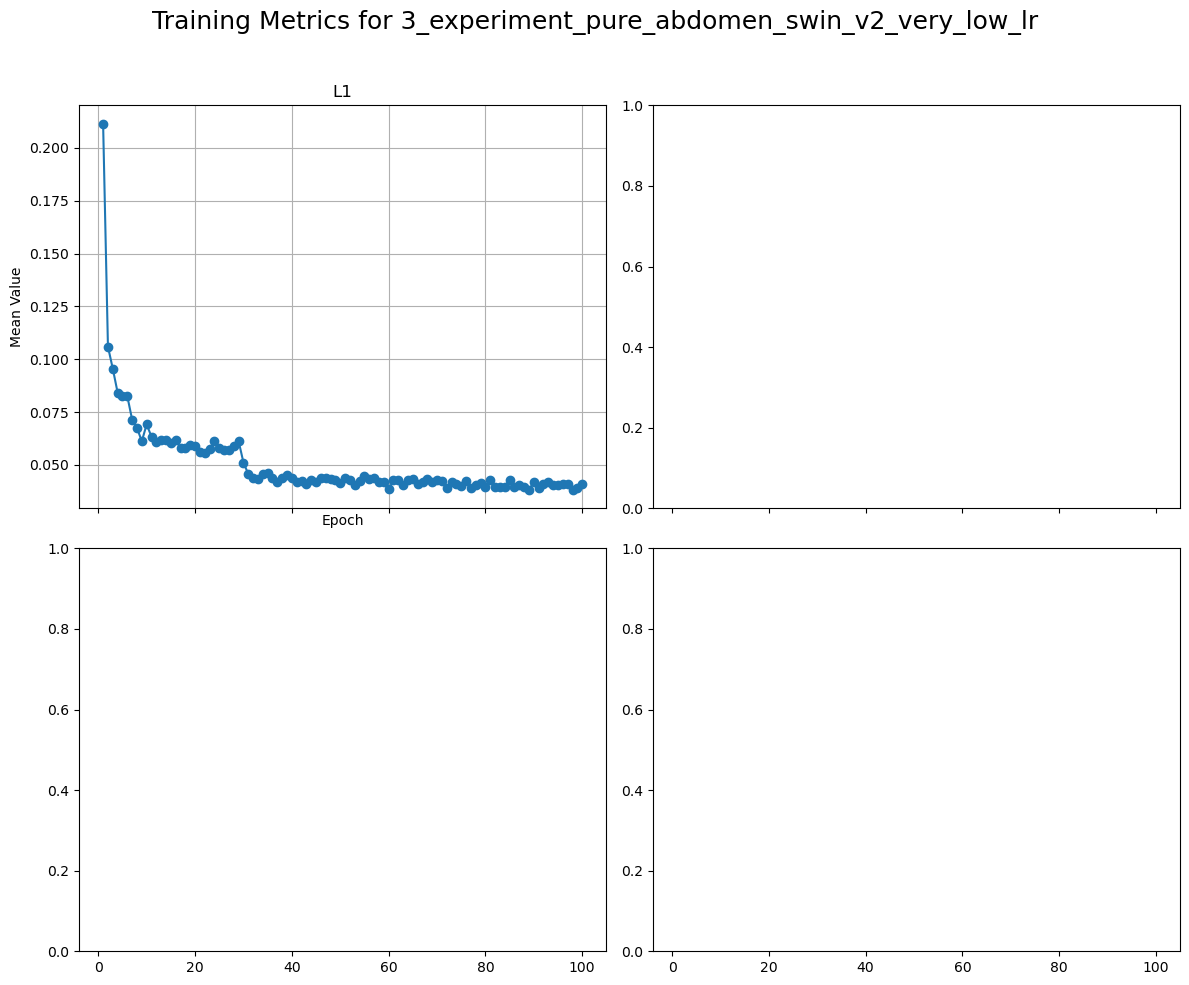

In [6]:
checkpoints_dir = "/local/scratch/datasets/FullbodySCT/Synthrad_combined_preprocessed/8checkpoints/"
name = "3_experiment_pure_abdomen_swin_v2_very_low_lr"

loss_log = parse_loss_log_pure_swin(checkpoints_dir+name+"/loss_log.txt")
plot_all_metric_means_per_epoch(loss_log, title=f"Training Metrics for {name}", metrics=["L1"])

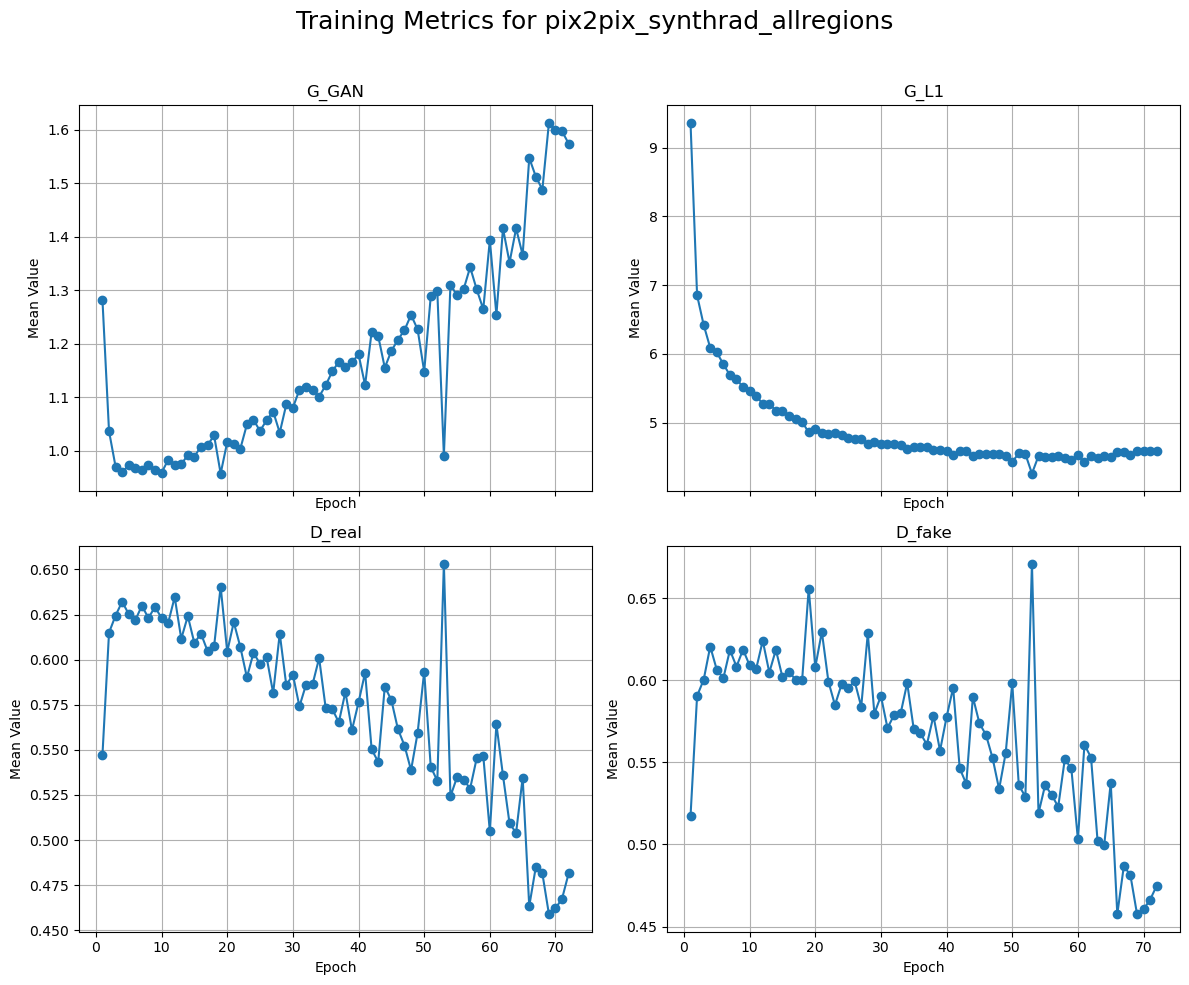

In [6]:
checkpoints_dir = "/home/user/fthuer/fullbody-sCT/training/checkpoints/"
name = "pix2pix_synthrad_allregions"

loss_log = parse_loss_log(checkpoints_dir+name+"/loss_log.txt")
plot_all_metric_means_per_epoch(loss_log, title=f"Training Metrics for {name}")